# Instalação

In [1]:
# Instala o uv (caso não esteja instalado no ambiente base)
%pip install uv

# Cria o ambiente virtual (.venv) no diretório atual e força a substituição se já existir
!uv venv --clear 

# Instala as bibliotecas necessárias
!uv pip install pandas numpy matplotlib scikit-learn imbalanced-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
Using CPython 3.13.12 interpreter at: c:\Users\User\AppData\Local\Programs\Python\Python313\python.exe
Creating virtual environment at: .venv
Activate with: .venv\Scripts\activate
Resolved 19 packages in 31ms
Installed 19 packages in 3.12s
 + contourpy==1.3.3
 + cycler==0.12.1
 + fonttools==4.62.1
 + imbalanced-learn==0.14.1
 + joblib==1.5.3
 + kiwisolver==1.5.0
 + matplotlib==3.10.8
 + numpy==2.4.4
 + packaging==26.0
 + pandas==3.0.2
 + pillow==12.2.0
 + pyparsing==3.3.2
 + python-dateutil==2.9.0.post0
 + scikit-learn==1.8.0
 + scipy==1.17.1
 + six==1.17.0
 + sklearn-compat==0.1.5
 + threadpoolctl==3.6.0
 + tzdata==2025.3


In [2]:
!uv pip install ipykernel

Resolved 28 packages in 47ms
Installed 25 packages in 2.11s
 + asttokens==3.0.1
 + colorama==0.4.6
 + comm==0.2.3
 + debugpy==1.8.20
 + decorator==5.2.1
 + executing==2.2.1
 + ipykernel==7.2.0
 + ipython==9.12.0
 + ipython-pygments-lexers==1.1.1
 + jedi==0.19.2
 + jupyter-client==8.8.0
 + jupyter-core==5.9.1
 + matplotlib-inline==0.2.1
 + nest-asyncio==1.6.0
 + parso==0.8.6
 + platformdirs==4.9.4
 + prompt-toolkit==3.0.52
 + psutil==7.2.2
 + pure-eval==0.2.3
 + pygments==2.20.0
 + pyzmq==27.1.0
 + stack-data==0.6.3
 + tornado==6.5.5
 + traitlets==5.14.3
 + wcwidth==0.6.0


In [3]:
!uv run python -m ipykernel install --user --name trabalho_vgsales --display-name "vgsales(uv)"


Installed kernelspec trabalho_vgsales in C:\Users\User\AppData\Roaming\jupyter\kernels\trabalho_vgsales


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

# Análise Exploratória (EDA)

In [2]:
df = pd.read_csv('vgsales.csv')
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  str    
 2   Platform      16598 non-null  str    
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  str    
 5   Publisher     16540 non-null  str    
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), str(4)
memory usage: 1.4 MB


**Dicionário de Dados (Significado das Features):**

*   **`0. Rank`**: id da tabela (será removido)
*   **`1. Name`**: nome do jogo (será removido)
*   **`2. Plataform`**: console na qual o jogo foi publicado (o target)
*   **`3. Year`**: ano de lançamento
*   **`4. Genre`**: genero do jogo
*   **`5. Publisher`**: empresa que publicou o jogo
*   **`6. NA_Sales`**: vendas na america do norte
*   **`7. EU_Sales`**: vendas na europa
*   **`8. JP_Sales`**: vendas no japão
*   **`9. Other_sales`**: vendas em outros paises
*   **`10. Global_Sales`**: venda total, por ser um valor que é apenas a soma das demais colunas de vendas, ele é um valor redundade, mas ele terá utilidade na aplicação do IQR (será removido)

In [4]:
df.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


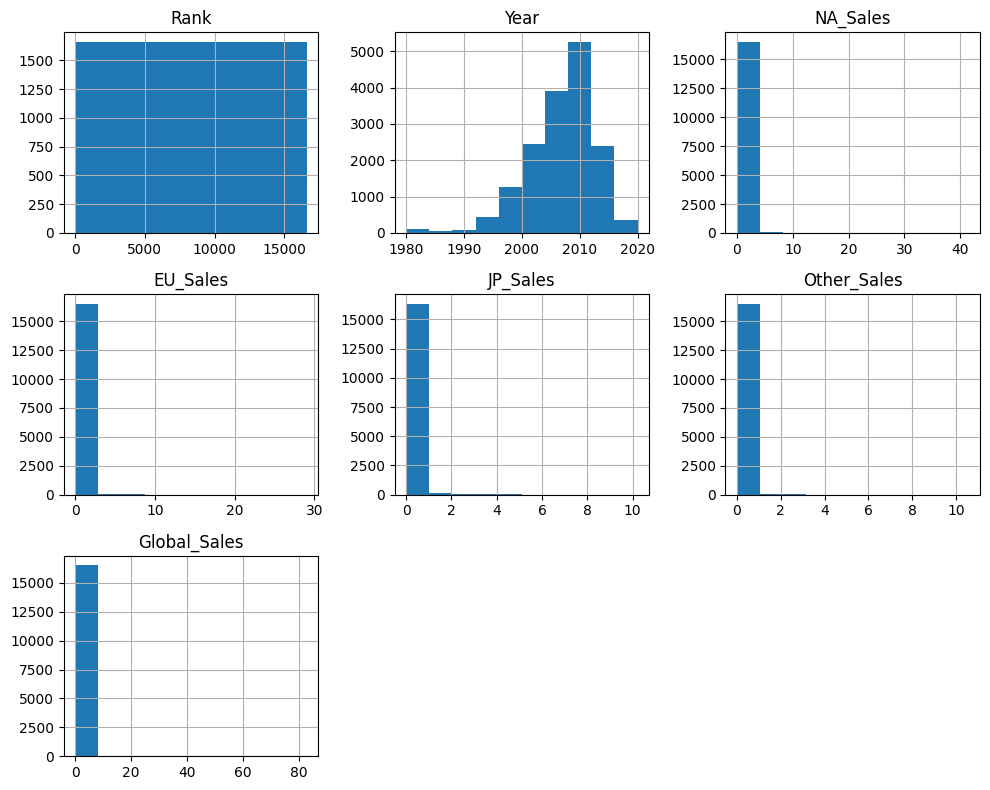

In [5]:
df.hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

# Limpeza

In [6]:
df = df.drop_duplicates() 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  str    
 2   Platform      16598 non-null  str    
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  str    
 5   Publisher     16540 non-null  str    
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), str(4)
memory usage: 1.4 MB


In [7]:
df.isnull().sum()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

In [8]:
df['Year'] = df['Year'].fillna(df['Year'].median())
df['Publisher'] = df['Publisher'].fillna(df['Publisher'].mode()[0])

# Tratamento de Outliers

Existem 5 colunas que seriam necessarias aplicar o IQR, porem podemos fazer isso apenas com o Global_Sales, a vantegem não é apenas executar menos codico, mas sim remover somente as linhas realmente necessarias, mantendo algum jogo de nicho em alguma região, so será removido aquele que vendeu demais em todos os lugares, ou seja, fora do padrão, que é o que o IQR concerta

Decedi ser menos "agressivo" na aplicação do IQR, coloquei a tolerancia pra 3.0 ao inves do padrão 1.5, ja que os jogos mais caracteristicos de um console é mais vendido, se usarmos 1.5 estariamos removendo um possivel dado importante, então com a tolerancia em 3.0, será removido apenas os que tiverem vendas "surreais"

In [9]:
# 1. Primeiro, usamos a Global_Sales para limpar os registros bizarros
Q1 = df['Global_Sales'].quantile(0.25)
Q3 = df['Global_Sales'].quantile(0.75)
IQR = Q3 - Q1

# Usando o fator 3.0 que você gostou (mais conservador)
lower = Q1 - 3.0 * IQR
upper = Q3 + 3.0 * IQR

print(f"Limite Inferior: {lower}")
print(f"Limite Superior: {upper}")

# Identificando quem está fora dos limites
outliers = df[(df['Global_Sales'] < lower) | (df['Global_Sales'] > upper)]
print(f"Quantidade de outliers encontrados: {len(outliers)}")


# Filtramos o DataFrame
df = df[(df['Global_Sales'] >= lower) & (df['Global_Sales'] <= upper)]

Limite Inferior: -1.17
Limite Superior: 1.7
Quantidade de outliers encontrados: 1048


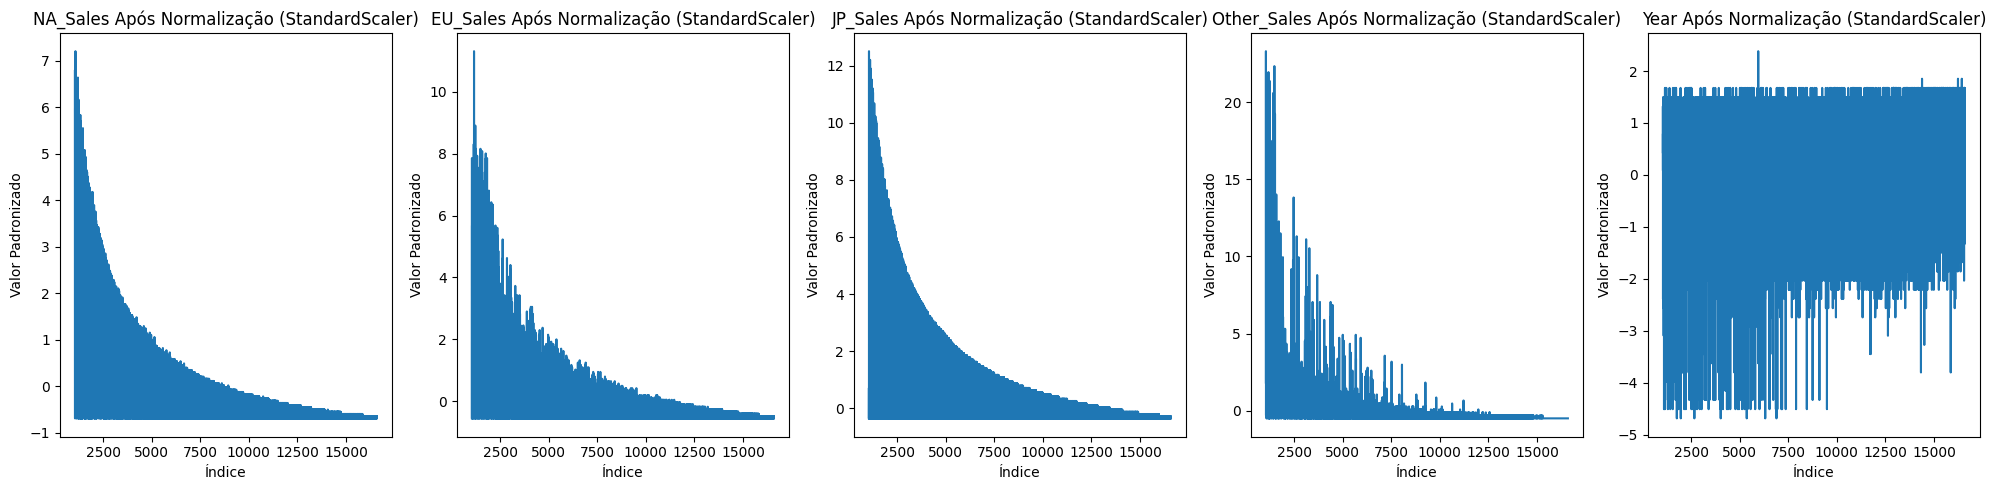

In [10]:
# criar scaler
scaler = StandardScaler()

cols_to_scale = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Year']
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

# visualizar
plt.figure(figsize=(20, 5))

for i, col in enumerate(cols_to_scale):
    plt.subplot(1, len(cols_to_scale), i+1)
    plt.plot(df[col])
    plt.title(f"{col} Após Normalização (StandardScaler)")
    plt.xlabel("Índice")
    plt.ylabel("Valor Padronizado")

plt.tight_layout()
plt.show()

# Transformações Estatísticas

In [11]:
colunas_vendas = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']

for col in colunas_vendas:
    df[col] = np.log1p(df[col])

print(df[colunas_vendas].head())

      NA_Sales  EU_Sales  JP_Sales  Other_Sales
1048  2.051162 -0.811013 -0.445336     1.042616
1049  0.650529  2.146915 -0.140253     1.712467
1050  0.334100  0.809827 -0.445336     3.190116
1051  1.607141  1.280893  0.534783     1.228612
1052  0.965261  2.181426 -0.445336     0.813936


# Encoding

Antes de transformar as colunas de texto em booleneano, decidi verificar quantas colunas serão adicionadas, ja que possuem muitas publicadoras e generos

In [12]:
# Contando valores únicos
n_generos = df['Genre'].nunique()
n_publishers = df['Publisher'].nunique()

print(f"Gêneros diferentes: {n_generos}")
print(f"Publishers diferentes: {n_publishers}")
print(f"Total estimado de novas colunas: {n_generos + n_publishers}")

Gêneros diferentes: 12
Publishers diferentes: 573
Total estimado de novas colunas: 585


Como imaginado, 573 colunas novas serão adicionadas ao usar o dummies, o que é um pouco inviavel, portanto decidi contornar criando uma nova publicadora chamada de "Other_Publishers", iriei substituir todas as publicadoras com menos de 50 jogos, ja que possue varias com poucos jogos registrados, que não é relevante saber qual exatamente ela é, a ideia focar nas mais famosas

So com esse ajuste o numero de 573 caiu pra 46, o que é uma boa melhoria

In [13]:
# Conta quantos jogos cada editora tem
counts = df['Publisher'].value_counts()

# Mantém o nome se tiver 50 ou mais jogos, senão vira 'Other_Publishers'
df['Publisher'] = df['Publisher'].apply(lambda x: x if counts[x] >= 50 else 'Other_Publishers')

print(f"Novo número de Publishers: {df['Publisher'].nunique()}")

Novo número de Publishers: 46


In [14]:
df = pd.get_dummies(df, columns=['Genre', 'Publisher'], drop_first=True)

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15550 entries, 1048 to 16597
Data columns (total 65 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Rank                                              15550 non-null  int64  
 1   Name                                              15550 non-null  str    
 2   Platform                                          15550 non-null  str    
 3   Year                                              15550 non-null  float64
 4   NA_Sales                                          15550 non-null  float64
 5   EU_Sales                                          15550 non-null  float64
 6   JP_Sales                                          15550 non-null  float64
 7   Other_Sales                                       15550 non-null  float64
 8   Global_Sales                                      15550 non-null  float64
 9   Genre_Adventure          

# Seleção de features

Aqui nos temos um problema, se tentar usar "y = le.fit_transform(df['Platform'])" vai dar erro na proxima etapa, entao será necessario remover classes muito raras

In [ ]:
#removendo
counts = df['Platform'].value_counts()
df = df[df['Platform'].isin(counts[counts >= 10].index)]

#seleção
le = LabelEncoder()
y = le.fit_transform(df['Platform']) #target
x = df.drop(columns=['Rank','Name','Global_Sales','Platform'])
df['Platform'].value_counts()

Platform
DS      2092
PS2     1987
Wii     1243
PS3     1205
PSP     1192
X360    1132
PS      1109
PC       924
XB       807
GBA      790
GC       541
3DS      480
PSV      411
N64      289
PS4      287
SNES     212
XOne     191
SAT      172
WiiU     133
2600     125
GB        65
NES       62
DC        50
GEN       20
NG        12
Name: count, dtype: int64

# Split do dataset

In [26]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

# Smote

In [27]:
smote = SMOTE(random_state=42)

x_train_res, y_train_res = smote.fit_resample(x_train, y_train)

print(f"Antes do SMOTE (Treino): {len(y_train)}")
print(f"Depois do SMOTE (Treino): {len(y_train_res)}")

Antes do SMOTE (Treino): 12424
Depois do SMOTE (Treino): 41825


# Treinamento do modelo

In [49]:
#Criando o modelo
arvores = RandomForestClassifier(class_weight='balanced', 
                                 n_estimators = 800, 
                                 max_depth = 30, 
                                 random_state = 42, 
                                 n_jobs = -1,
                                 min_samples_leaf=1)

# Treinando o modelo
arvores.fit(x_train_res, y_train_res)

# Gerando as previsões
previsao = arvores.predict(x_test)

In [50]:
accuracy_score(y_test, previsao)

0.566784679755391

In [51]:
print(classification_report(y_test, previsao))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        25
           1       0.29      0.28      0.29        96
           2       0.67      0.80      0.73        10
           3       0.53      0.50      0.51       419
           4       0.64      0.54      0.58        13
           5       0.68      0.65      0.67       158
           6       0.40      0.44      0.42       108
           7       1.00      0.50      0.67         4
           8       0.83      0.84      0.84        58
           9       0.90      0.75      0.82        12
          10       1.00      0.50      0.67         2
          11       0.69      0.77      0.73       185
          12       0.87      0.90      0.88       222
          13       0.81      0.77      0.79       398
          14       0.44      0.37      0.40       241
          15       0.43      0.47      0.45        57
          16       0.51      0.47      0.49       239
          17       0.48    